Columns in dataset:
 Index(['Timestamp', 'Temperature(C)', 'Humidity(%)', 'Light_Intensity(lx)',
       'Motion'],
      dtype='object')

Target Column: Temperature(C)
Feature Columns: ['Humidity(%)', 'Light_Intensity(lx)']


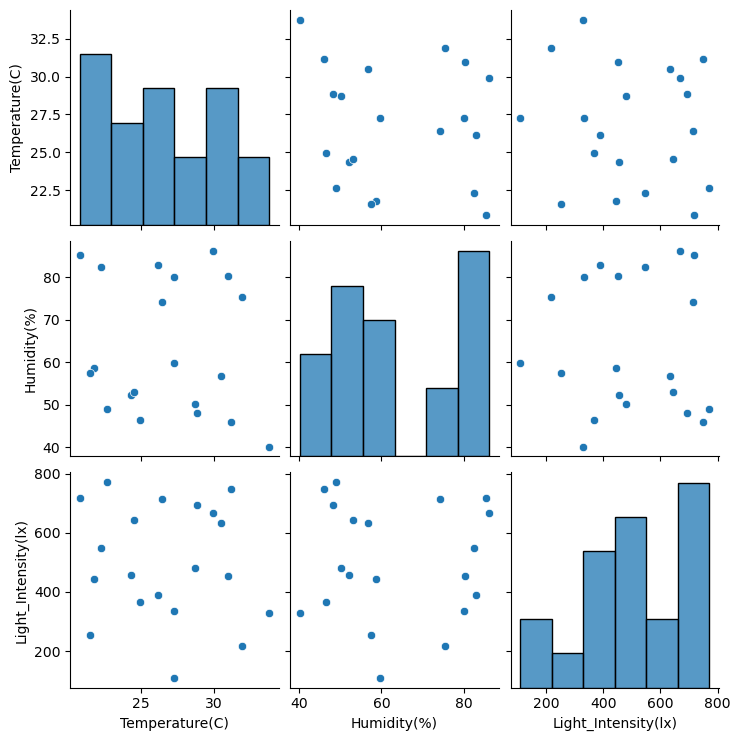

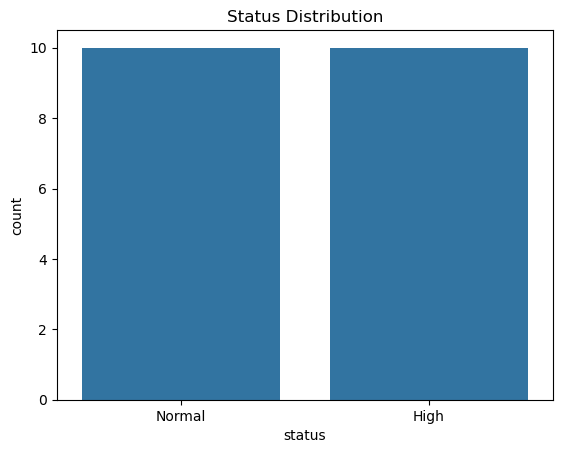


Classification Results:
            Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.500000       0.50  0.333333  0.400000
1  Decision Tree  0.166667       0.25  0.333333  0.285714


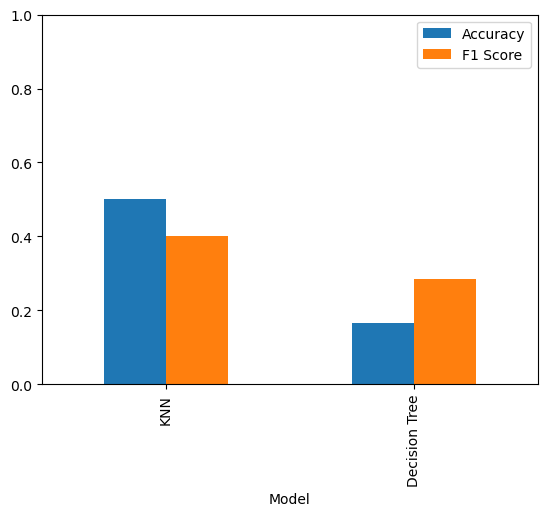


Regression Results:
              Model       MAE      RMSE        R2
0           Linear  3.195576  3.715091  0.016443
1  Multiple Linear  3.443772  3.931137 -0.824341
2    Decision Tree  5.186667  5.520220 -2.597349


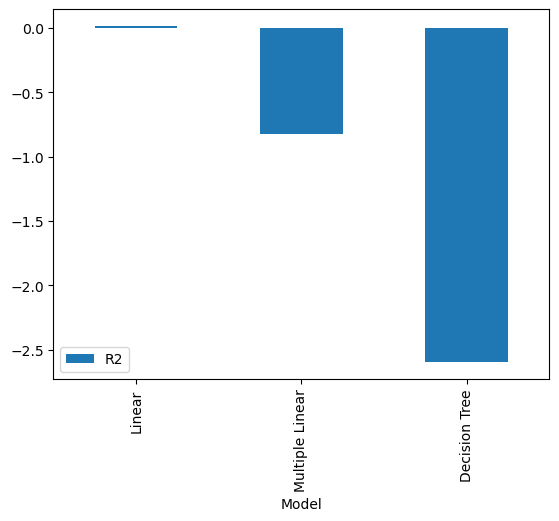

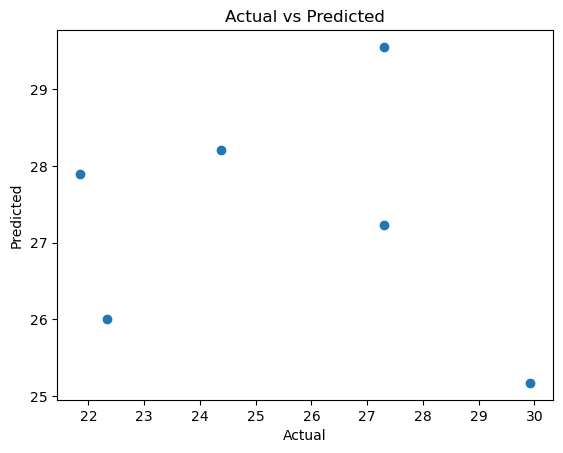

In [1]:
# ===============================
# ML ALGORITHM COMPARISON
# AUTO COLUMN SAFE VERSION
# Dataset: iot_sensor_data.csv
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# ----------- Load Dataset -----------
df = pd.read_csv("iot_sensor_data.csv")
print("Columns in dataset:\n", df.columns)

# ----------- Identify Numeric Columns -----------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) < 3:
    raise ValueError("Dataset must have at least 3 numeric columns")

# Target = first numeric column
target_col = numeric_cols[0]

# Features = next two numeric columns
feature_cols = numeric_cols[1:3]

print("\nTarget Column:", target_col)
print("Feature Columns:", feature_cols)

# ----------- Targets -----------
y_reg = df[target_col]

df["status"] = y_reg.apply(lambda x: "High" if x >= y_reg.mean() else "Normal")
y_class = df["status"]

X = df[feature_cols]

# ----------- Visualization -----------
sns.pairplot(df[[target_col] + feature_cols])
plt.show()

sns.countplot(x="status", data=df)
plt.title("Status Distribution")
plt.show()

# ======================================
# CLASSIFICATION
# ======================================

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.3, random_state=42
)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s = scaler.transform(Xc_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_train_s, yc_train)
knn_pred = knn.predict(Xc_test_s)

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(Xc_train, yc_train)
dt_pred = dt_clf.predict(Xc_test)

cls_results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(yc_test, knn_pred),
        accuracy_score(yc_test, dt_pred)
    ],
    "Precision": [
        precision_score(yc_test, knn_pred, pos_label="High"),
        precision_score(yc_test, dt_pred, pos_label="High")
    ],
    "Recall": [
        recall_score(yc_test, knn_pred, pos_label="High"),
        recall_score(yc_test, dt_pred, pos_label="High")
    ],
    "F1 Score": [
        f1_score(yc_test, knn_pred, pos_label="High"),
        f1_score(yc_test, dt_pred, pos_label="High")
    ]
})

print("\nClassification Results:\n", cls_results)

cls_results.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
plt.ylim(0, 1)
plt.show()

# ======================================
# REGRESSION
# ======================================

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X[[feature_cols[0]]], y_reg)
lr_pred = lr.predict(X[[feature_cols[0]]])

mlr = LinearRegression()
mlr.fit(Xr_train, yr_train)
mlr_pred = mlr.predict(Xr_test)

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(Xr_train, yr_train)
dt_reg_pred = dt_reg.predict(Xr_test)

reg_results = pd.DataFrame({
    "Model": ["Linear", "Multiple Linear", "Decision Tree"],
    "MAE": [
        mean_absolute_error(y_reg, lr_pred),
        mean_absolute_error(yr_test, mlr_pred),
        mean_absolute_error(yr_test, dt_reg_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_reg, lr_pred)),
        np.sqrt(mean_squared_error(yr_test, mlr_pred)),
        np.sqrt(mean_squared_error(yr_test, dt_reg_pred))
    ],
    "R2": [
        r2_score(y_reg, lr_pred),
        r2_score(yr_test, mlr_pred),
        r2_score(yr_test, dt_reg_pred)
    ]
})

print("\nRegression Results:\n", reg_results)

reg_results.set_index("Model")[["R2"]].plot(kind="bar")
plt.show()

plt.scatter(yr_test, mlr_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()